In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv("/content/diabetes_clean.csv")

In [25]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [26]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,125,33.6,0.627,50,1
1,1,85,66,29,125,26.6,0.351,31,0
2,8,183,64,29,125,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,52,35,168,43.1,1.136,33,1


In [27]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

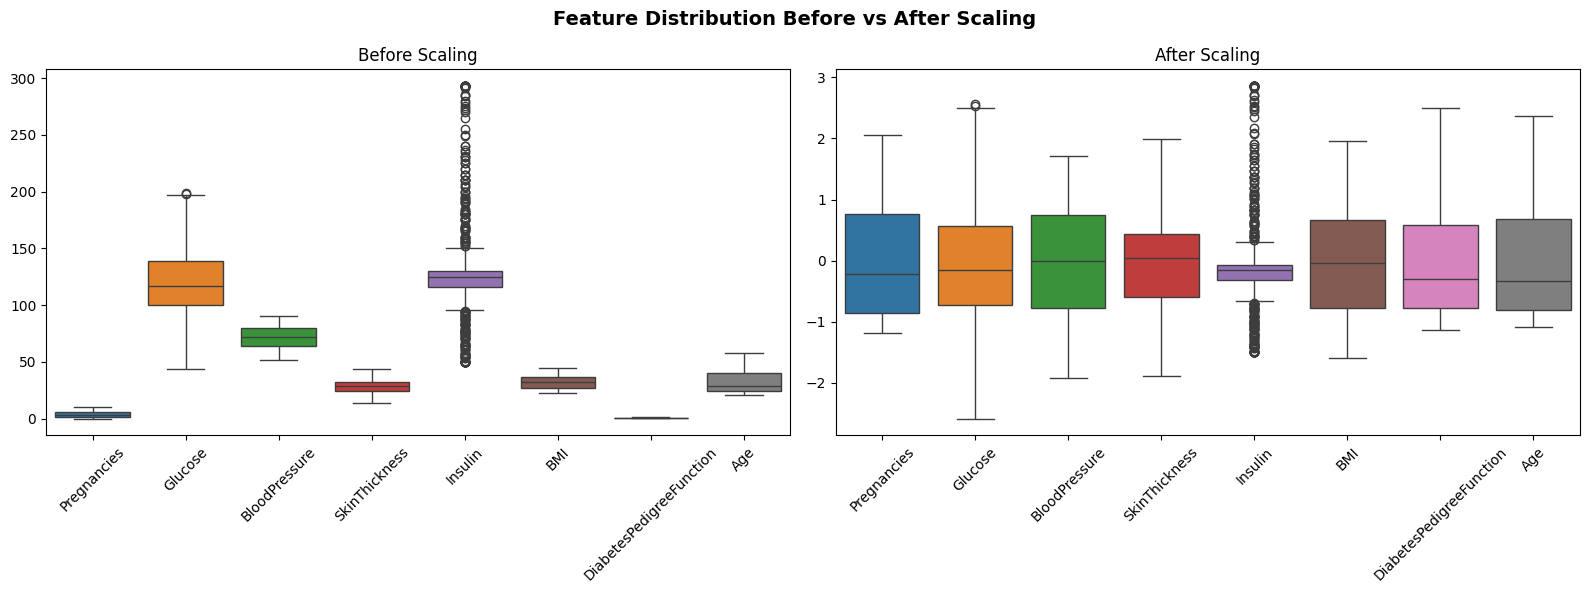

In [30]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=X_train, ax=axes[0])
axes[0].set_title('Before Scaling')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=X_train_scaled_df, ax=axes[1])
axes[1].set_title('After Scaling')
axes[1].tick_params(axis='x', rotation=45)

fig.suptitle("Feature Distribution Before vs After Scaling", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
X_train.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = [
    {'penalty': ['l2'],
     'solver': ['lbfgs', 'newton-cg', 'sag'],
     'C': [0.01, 0.1, 1, 10, 100],
     'class_weight': ['balanced', None]},
    {'penalty': ['l1', 'l2'],
     'solver': ['liblinear', 'saga'],
     'C': [0.01, 0.1, 1, 10, 100],
     'class_weight': ['balanced', None]},
    {'penalty': ['elasticnet'],
     'solver': ['saga'],
     'C': [0.01, 0.1, 1, 10, 100],
     'l1_ratio': [0.3, 0.5, 0.7],
     'class_weight': ['balanced', None]}
]

grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Params:", grid_search.best_params_)

y_pred = grid_search.predict(X_test_scaled)
y_pred_proba = grid_search.predict_proba(X_test_scaled)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))

Best Params: {'C': 0.1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.7467532467532467
ROC AUC: 0.8165289256198347


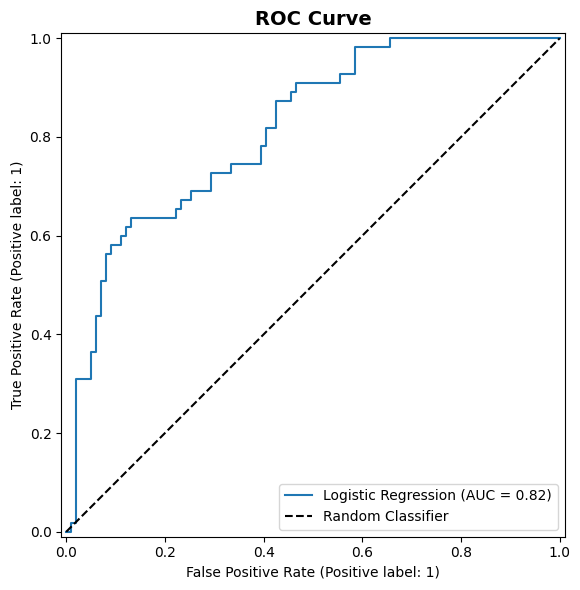

In [33]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba,
    name="Logistic Regression",
    ax=ax
)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [34]:
X_train.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [35]:
import pickle

# Save
with open('diabetes_model.pkl', 'wb') as f:
    pickle.dump(grid_search.best_estimator_, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)